## Oura Ring 4 Sentiment Analysis and Oura Ring 5 Future Prediction

### 1. Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)


### 2. Loading the preprocessd dataset

In [ ]:
df = pd.read_csv("oura_ring4_all_reviews.xls")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (4240, 9)

Columns:
['review_id', 'source', 'rating', 'title', 'body', 'review_date', 'verified', 'helpful_votes', 'scraped_at']


,review_id,source,rating,title,body,review_date,verified,helpful_votes,scraped_at
0,target_00000,target,5,Loving My Ōura Ring,So far loving my Ōura ring! It’s not been unco...,"18 March, 2026",False,0,2026-03-28T15:37:14Z
1,target_00001,target,5,Useful & Convenient,I bought my Oura ring in store and sized using...,"11 March, 2026",False,0,2026-03-28T15:37:14Z
2,target_00002,target,2,Lasted less than 1 year,I purchased this item in March 2025. Loved it....,"11 March, 2026",False,0,2026-03-28T15:37:14Z
3,target_00003,target,1,(no review title),Stopped working completely after 1.5 years. Ba...,"9 March, 2026",False,0,2026-03-28T15:37:14Z
4,target_00004,target,5,A great investment,I wanted to share my 6-month review of the Our...,"6 March, 2026",False,0,2026-03-28T15:37:14Z


### 3. Conform that BODY is the review text column we want to use

In [ ]:
df["body"] = df["body"].astype(str)

df[["title", "body"]].head(10)

,title,body
0,Loving My Ōura Ring,So far loving my Ōura ring! It’s not been unco...
1,Useful & Convenient,I bought my Oura ring in store and sized using...
2,Lasted less than 1 year,I purchased this item in March 2025. Loved it....
3,(no review title),Stopped working completely after 1.5 years. Ba...
4,A great investment,I wanted to share my 6-month review of the Our...
5,Sill Waiting,Still haven’t received my order. It was suppos...
6,Expensive piece of crap,An expensive piece of crap that only was funci...
7,Overpriced ring that wont last,I’ve had a ring for just over a year and the b...
8,(no review title),Why did my ring come unsealed. Was it used?
9,Electronics deparment,Thank you to the kind gentleman that helped me...


## 4. Turning all review text into lowercase and cleaning it

- lowercases the review text
- removes punctuation
- removes numbers
- removes extra spaces


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)   # remove punctuation
    text = re.sub(r"\d+", "", text)        # remove numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df["clean_body"] = df["body"].apply(clean_text)

df[["body", "clean_body"]].head(10)


,body,clean_body
0,So far loving my Ōura ring! It’s not been unco...,so far loving my ōura ring its not been uncomf...
1,I bought my Oura ring in store and sized using...,i bought my oura ring in store and sized using...
2,I purchased this item in March 2025. Loved it....,i purchased this item in march loved it fast f...
3,Stopped working completely after 1.5 years. Ba...,stopped working completely after years battery...
4,I wanted to share my 6-month review of the Our...,i wanted to share my month review of the oura ...
5,Still haven’t received my order. It was suppos...,still havent received my order it was supposed...
6,An expensive piece of crap that only was funci...,an expensive piece of crap that only was funci...
7,I’ve had a ring for just over a year and the b...,ive had a ring for just over a year and the ba...
8,Why did my ring come unsealed. Was it used?,why did my ring come unsealed was it used
9,Thank you to the kind gentleman that helped me...,thank you to the kind gentleman that helped me...


### 5. Stopword removal

We inspect the NLTK stopword list and customize it by **keeping words that matter for sentiment**, especially:
- negation words like `not`, `no`, `never`
- expectation words like `should` and `need`

Keeping these words helps preserve negative opinions and unmet customer needs.


In [ ]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# inspecting the stopword list
print(sorted(stop_words))


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to C:\Users\Christine
[nltk_data]     Whelan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 5.1 Words we want to keep

In [ ]:
important_words = {"not", "no", "never", "should", "need"}

# Remove these from the stopword list so they stay in the text
stop_words = stop_words - important_words

print("Preserved words still in stopword list?")
for word in sorted(important_words):
    print(f"{word}: {word in stop_words}")


Preserved words still in stopword list?
need: False
never: False
no: False
not: False
should: False


### 5.2 Removing the remaining stopwords

In [ ]:
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df["clean_body"] = df["clean_body"].apply(remove_stopwords)

df[["body", "clean_body"]].head(10)


,body,clean_body
0,So far loving my Ōura ring! It’s not been unco...,far loving ōura ring not uncomfortable not pur...
1,I bought my Oura ring in store and sized using...,bought oura ring store sized using sizers stor...
2,I purchased this item in March 2025. Loved it....,purchased item march loved fast forward march ...
3,Stopped working completely after 1.5 years. Ba...,stopped working completely years battery used ...
4,I wanted to share my 6-month review of the Our...,wanted share month review oura ring considerin...
5,Still haven’t received my order. It was suppos...,still havent received order supposed delivered...
6,An expensive piece of crap that only was funci...,expensive piece crap funcional months lot conn...
7,I’ve had a ring for just over a year and the b...,ive ring year batteries horrible might apply y...
8,Why did my ring come unsealed. Was it used?,ring come unsealed used
9,Thank you to the kind gentleman that helped me...,thank kind gentleman helped questions ring als...


### 6. Saving the cleaned file

In [ ]:
df.to_csv("oura_ring4_all_reviews_preprocessed.csv", index=False)

### 7. Inspecting the cleaned data

In [ ]:
print(df.info())
print("\nRating distribution:")
print(df["rating"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_id      4240 non-null   object
 1   source         4240 non-null   object
 2   rating         4240 non-null   int64 
 3   title          4240 non-null   object
 4   body           4240 non-null   object
 5   review_date    4226 non-null   object
 6   verified       4240 non-null   bool  
 7   helpful_votes  4240 non-null   int64 
 8   scraped_at     4240 non-null   object
 9   clean_body     4240 non-null   object
dtypes: bool(1), int64(2), object(7)
memory usage: 302.4+ KB
None

Rating distribution:
rating
1     298
2     172
3     236
4     473
5    3061
Name: count, dtype: int64


### 8. Creating sentiment labels from star ratings

We will use:
- **1–2 stars = negative (0)**
- **4–5 stars = positive (1)**
- **3 stars = neutral / removed**


In [ ]:
def label_sentiment(rating):
    if rating in [1, 2]:
        return 0   # negative
    elif rating in [4, 5]:
        return 1   # positive
    else:
        return np.nan   # neutral (3-star)

df["sentiment"] = df["rating"].apply(label_sentiment)

# remove neutral reviews
df_model = df.dropna(subset=["sentiment"]).copy()
df_model["sentiment"] = df_model["sentiment"].astype(int)

print(df_model["sentiment"].value_counts())

sentiment
1    3534
0     470
Name: count, dtype: int64


### Why this is important for our project:
We need a target variable for classification.
Using stars as the gold-standard label is common and easy to justify:
- low ratings reflect dissatisfaction
- high ratings reflect satisfaction
- 3-star reviews are mixed and can muddy the model

### 9. Keeping only usable review text

In [ ]:
df_model = df_model[df_model["clean_body"].notna()].copy()
df_model = df_model[df_model["clean_body"].str.strip() != ""].copy()

X_text = df_model["clean_body"]
y = df_model["sentiment"]

print("Number of reviews used:", len(df_model))

Number of reviews used: 4002


Removed:
- missing text
- blank text

Models cannot learn from empty reviews.

### 10. Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3201
Test size: 801


### 11. TF-IDF feature representation

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)


X_train_tfidf shape: (3201, 4865)
X_test_tfidf shape: (801, 4865)


### Why TF-IDF?
- captures important words
- downweights very common words
- usually works well for sentiment classification

### 12. Training Multiple Models

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

### 13. Evaluating the Models

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
2           Linear SVM  0.940075   0.966054  0.966054  0.966054
3        Random Forest  0.930087   0.938089  0.985856  0.961379
1  Logistic Regression  0.930087   0.977974  0.942008  0.959654
0          Naive Bayes  0.908864   0.910622  0.994342  0.950642


While Linear SVM achieved the highest F1 score (0.966), Logistic Regression performed nearly as well (F1 = 0.959) and was selected as the final model due to its interpretability. Logistic Regression allows for easier analysis of feature importance, enabling us to identify key words and phrases driving positive and negative sentiment in Oura Ring 4 reviews.

### 14. Final Model Selection

In [ ]:
best_model = LogisticRegression(max_iter=2000, class_weight="balanced")
best_model.fit(X_train_tfidf, y_train)

y_pred_best = best_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.66      0.84      0.74        94
           1       0.98      0.94      0.96       707

    accuracy                           0.93       801
   macro avg       0.82      0.89      0.85       801
weighted avg       0.94      0.93      0.93       801

[[ 79  15]
 [ 41 666]]


- 15 negatives misclassified as positive
- 41 positives misclassified as negative
- The model is slightly biased toward predicting positive sentiment, likely due to the imbalance in the dataset where positive reviews dominate.

### 15. Confusion Matrix

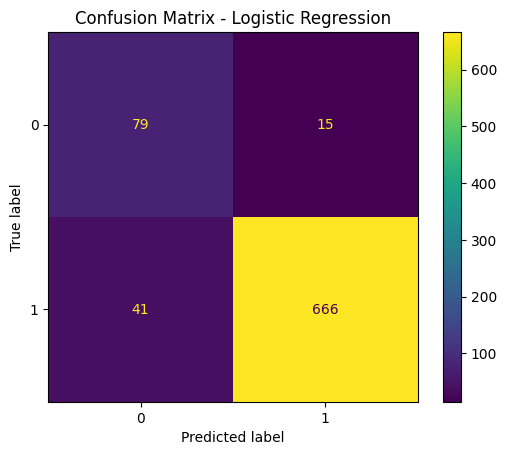

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows how well the model separates positive and negative Oura Ring 4 reviews. Correct classifications appear on the diagonal, while off-diagonal values represent misclassifications. This helps illustrate whether the model is better at recognizing positive sentiment or negative sentiment.

### 16. Most important positive and negative words

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = best_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-20:]
top_negative_idx = np.argsort(coefficients)[:20]

top_positive_words = pd.DataFrame({
    "word": feature_names[top_positive_idx],
    "coefficient": coefficients[top_positive_idx]
}).sort_values(by="coefficient", ascending=False)

top_negative_words = pd.DataFrame({
    "word": feature_names[top_negative_idx],
    "coefficient": coefficients[top_negative_idx]
}).sort_values(by="coefficient", ascending=True)

print("Top Positive Words")
print(top_positive_words)

print("\nTop Negative Words")
print(top_negative_words)

Top Positive Words
           word  coefficient
19         love     5.083970
18        great     3.724676
17       health     3.293000
16        sleep     2.293970
15         easy     2.082103
14        loves     1.976886
13    love ring     1.901217
12  comfortable     1.849705
11      amazing     1.783095
10         wife     1.768124
9         happy     1.766497
8     oura ring     1.666555
7       perfect     1.624690
6          good     1.581473
5        tracks     1.574116
4          body     1.493081
3    everything     1.491719
2        helped     1.450302
1           far     1.420998
0     excellent     1.419150

Top Negative Words
            word  coefficient
0            not    -6.405568
1         months    -3.487363
2             no    -3.090872
3         return    -2.476811
4        stopped    -2.420168
5           year    -2.419148
6         doesnt    -2.389756
7          didnt    -2.316851
8          weeks    -2.315266
9   disappointed    -2.305039
10          less    -2

Positive reviews are strongly associated with words like “love,” “great,” “amazing,” and “perfect,” indicating overall high satisfaction with the Oura Ring 4. Functional benefits such as sleep tracking and health insights also appear frequently, suggesting that users value the ring’s core features. Additionally, terms like “comfortable” and “easy” highlight positive experiences with usability and wearability.

Negative sentiment is driven by words such as “not,” “no,” and “never,” indicating dissatisfaction or unmet expectations. Terms like “stopped,” “broken,” and “disappointing” suggest product reliability issues. Additionally, words like “return,” “returned,” and “returning” indicate that customers frequently return the product, potentially due to defects or dissatisfaction. Time-related words such as “month” and “weeks” may point to issues arising after short-term use.

The model does not only identify individual words but also captures broader themes in customer sentiment. Positive sentiment is associated with product benefits (sleep tracking, comfort), while negative sentiment highlights product reliability issues and return experiences.

### 17. Most common words in positive and negative reviews

In [ ]:
positive_text = " ".join(df_model[df_model["sentiment"] == 1]["clean_body"])
negative_text = " ".join(df_model[df_model["sentiment"] == 0]["clean_body"])

positive_counts = Counter(positive_text.split()).most_common(20)
negative_counts = Counter(negative_text.split()).most_common(20)

print("Most common words in positive reviews:")
print(positive_counts)

print("\nMost common words in negative reviews:")
print(negative_counts)

Most common words in positive reviews:
[('ring', 2453), ('sleep', 1340), ('love', 1324), ('oura', 996), ('great', 935), ('health', 864), ('tracking', 484), ('battery', 469), ('like', 454), ('track', 430), ('app', 412), ('really', 392), ('life', 386), ('watch', 377), ('good', 376), ('easy', 368), ('data', 365), ('comfortable', 363), ('product', 358), ('im', 355)]

Most common words in negative reviews:
[('ring', 550), ('not', 311), ('oura', 220), ('no', 129), ('battery', 122), ('sleep', 122), ('would', 101), ('data', 100), ('months', 97), ('days', 95), ('get', 94), ('even', 90), ('im', 90), ('year', 88), ('product', 88), ('charge', 86), ('like', 85), ('day', 81), ('buy', 80), ('dont', 76)]


The analysis reveals that customer sentiment is not driven by different features, but rather by differing experiences with the same features. For example, while some users praise the battery and sleep tracking capabilities, others report issues with battery life and data accuracy.

### 18. Topic modeling

This helps group the review text into broader product themes such as sleep, battery, comfort, and app experience

In [ ]:
count_vectorizer = CountVectorizer(max_features=3000, min_df=5, max_df=0.9)
X_count = count_vectorizer.fit_transform(df_model["clean_body"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_count)

topic_feature_names = count_vectorizer.get_feature_names_out()

def display_topics(model, feature_names, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-no_top_words:]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

display_topics(lda, topic_feature_names)

Topic 1: stress, tracks, tracking, oura, track, great, health, love, ring, sleep
Topic 2: use, good, really, like, get, data, subscription, app, not, ring
Topic 3: sizing, bought, wife, one, loves, best, great, buy, size, ring
Topic 4: tracking, love, insights, days, ive, sleep, life, oura, ring, battery
Topic 5: apple, got, watch, love, no, im, like, not, oura, ring


### 19. Aspect Based sentiment analysis

We defined product aspects based on our results and calculate average sentiment for each aspect.
A score closer to **1** means more positive reviews for that aspect.


In [ ]:
aspects = {
    "battery": ["battery", "charge", "charging"],
    "sleep": ["sleep", "tracking", "track"],
    "comfort": ["comfortable", "comfort", "fit", "wear"],
    "app": ["app", "data", "sync"],
    "durability": ["broken", "stopped", "return", "returned", "returning"]
}

aspect_scores = defaultdict(list)

for _, row in df_model.iterrows():
    text = row["clean_body"]
    sentiment = row["sentiment"]

    for aspect, keywords in aspects.items():
        if any(word in text for word in keywords):
            aspect_scores[aspect].append(sentiment)

### 20. Building an aspect summary table with sentiment, mentions and priority

In [ ]:
aspect_summary = pd.DataFrame([
    {
        "aspect": k,
        "avg_sentiment": sum(v) / len(v),
        "mentions": len(v)
    }
    for k, v in aspect_scores.items()
])

# Higher priority score = lower sentiment + more mentions
aspect_summary["priority_score"] = (
    (1 - aspect_summary["avg_sentiment"])**2 * aspect_summary["mentions"]
).round(1)

aspect_summary = aspect_summary.sort_values(by="priority_score", ascending=False)
aspect_summary


,aspect,avg_sentiment,mentions,priority_score
4,durability,0.261364,176,96.0
2,battery,0.776871,735,36.6
3,app,0.837739,1097,28.9
1,comfort,0.907480,1016,8.7
0,sleep,0.939146,1709,6.3


### 21. Visualizing aspect sentiment and mention volume

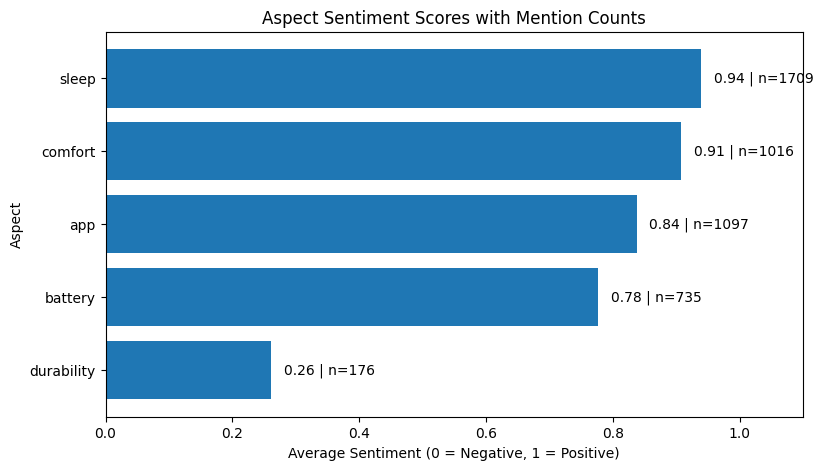

In [ ]:
aspect_plot = aspect_summary.sort_values(by="priority_score", ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.barh(aspect_plot["aspect"], aspect_plot["avg_sentiment"])

for i, bar in enumerate(bars):
    plt.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{aspect_plot['avg_sentiment'].iloc[i]:.2f} | n={aspect_plot['mentions'].iloc[i]}",
        va="center"
    )

plt.title("Aspect Sentiment Scores with Mention Counts")
plt.xlabel("Average Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Aspect")
plt.xlim(0, 1.1)
plt.show()

### 22. Showing positive vs negative review counts for each aspect

In [ ]:
aspect_distribution = []

for aspect, keywords in aspects.items():
    subset = df_model[df_model["clean_body"].apply(lambda x: any(word in x for word in keywords))]

    if len(subset) > 0:
        pos = sum(subset["sentiment"] == 1)
        neg = sum(subset["sentiment"] == 0)

        aspect_distribution.append({
            "aspect": aspect,
            "positive": pos,
            "negative": neg,
            "total_mentions": len(subset)
        })

aspect_dist_df = pd.DataFrame(aspect_distribution).sort_values(by="negative", ascending=False)
aspect_dist_df

,aspect,positive,negative,total_mentions
3,app,919,178,1097
0,battery,571,164,735
4,durability,46,130,176
1,sleep,1605,104,1709
2,comfort,922,94,1016


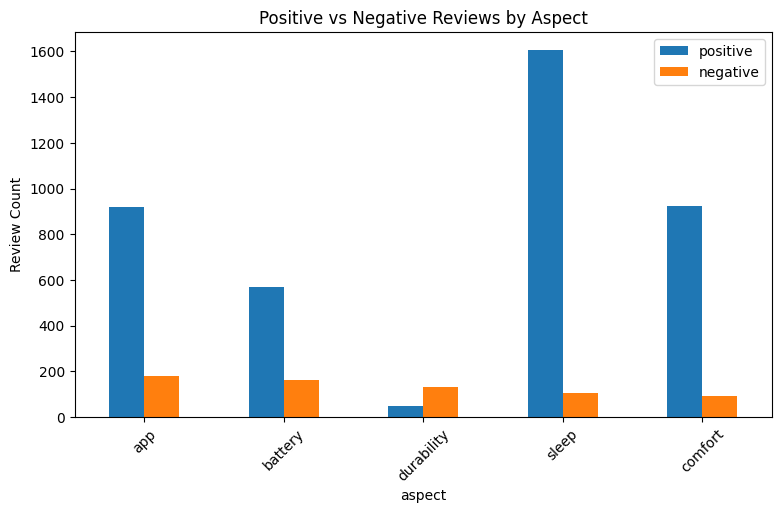

In [ ]:
aspect_dist_df.set_index("aspect")[["positive", "negative"]].plot(kind="bar", figsize=(9, 5))
plt.title("Positive vs Negative Reviews by Aspect")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

### 23. Finding the most common words within each aspect

In [ ]:
generic_words = {"ring", "oura", "product"}

for aspect, keywords in aspects.items():
    subset = df_model[
        df_model["clean_body"].apply(lambda x: any(word in x for word in keywords))
    ]

    text = " ".join(subset["clean_body"])
    common_words = Counter(text.split()).most_common(20)

    filtered_words = [
        (word, count) for word, count in common_words
        if word not in generic_words
    ][:10]

    print(f"\nTop words for {aspect}:")
    print(filtered_words)


Top words for battery:
[('battery', 591), ('life', 348), ('sleep', 340), ('charge', 270), ('great', 244), ('days', 241), ('love', 235), ('not', 218), ('app', 180), ('health', 177)]

Top words for sleep:
[('sleep', 1462), ('love', 654), ('health', 571), ('tracking', 538), ('track', 460), ('great', 449), ('not', 314), ('like', 307), ('battery', 307), ('data', 290)]

Top words for comfort:
[('sleep', 538), ('wear', 378), ('comfortable', 376), ('love', 332), ('health', 318), ('great', 273), ('not', 271), ('tracking', 243), ('data', 239), ('like', 235)]

Top words for app:
[('sleep', 567), ('app', 480), ('data', 465), ('love', 382), ('watch', 307), ('health', 306), ('not', 302), ('great', 267), ('battery', 251), ('apple', 245)]

Top words for durability:
[('not', 111), ('stopped', 74), ('return', 63), ('sleep', 62), ('no', 52), ('working', 47), ('would', 45), ('size', 45), ('returned', 44), ('like', 42)]


### 24. Extract representative review evidence

In [ ]:
def get_representative_reviews(df_in, aspect_name, aspect_keywords, sentiment_value, n=3):
    subset = df_in[df_in["sentiment"] == sentiment_value].copy()

    subset = subset[
        subset["clean_body"].apply(
            lambda x: sum(word in x for word in aspect_keywords) >= 2
        )
    ].copy()

    subset["review_length"] = subset["body"].astype(str).str.len()

    return subset.sort_values(
        by="review_length", ascending=False
    )[["title", "body", "rating"]].head(n)

for aspect, keywords in aspects.items():
    print(f"\n{'='*80}")
    print(f"REPRESENTATIVE NEGATIVE REVIEWS FOR: {aspect.upper()}")
    display(get_representative_reviews(df_model, aspect, keywords, sentiment_value=0, n=3))

    print(f"\nREPRESENTATIVE POSITIVE REVIEWS FOR: {aspect.upper()}")
    display(get_representative_reviews(df_model, aspect, keywords, sentiment_value=1, n=3))


REPRESENTATIVE NEGATIVE REVIEWS FOR: BATTERY


,title,body,rating
329,Phenomenal Sleep Tracker With a Terrible Battery,I bought this in January 2025 and it truly imp...,2
360,Inconsistent hardware experience,I’ve been using the Oura Ring 4 for about a mo...,2
349,"0 out of 10 stars, will never recommend again.",I purchased the Oura Ring Gen 4 (Stealth) dire...,2



REPRESENTATIVE POSITIVE REVIEWS FOR: BATTERY


,title,body,rating
4182,Has a nice ring to it,Tech Insider Network MemberTop 1000 Contributo...,4
523,"Great data, once you're past the paywall. Batt...",This has transformed how I view and evaluate m...,4
506,Smart ring useful for tracking some health sta...,"This version of the Oura works OK, but I proba...",4



REPRESENTATIVE NEGATIVE REVIEWS FOR: SLEEP


...

,title,body,rating
599,1 Month Post Purchase Review,"Overall, I love it. I’m gonna break down my re...",5
4182,Has a nice ring to it,Tech Insider Network MemberTop 1000 Contributo...,4
506,Smart ring useful for tracking some health sta...,"This version of the Oura works OK, but I proba...",4



REPRESENTATIVE NEGATIVE REVIEWS FOR: DURABILITY


,title,body,rating
385,Very disappointed - So inaccurate with most me...,Extremely disappointed. I was very excited for...,2
30,Read before purchasing - Things to consider...,I received this as a gift. I wouldn't have bou...,2
4232,Ridiculous that you have to charge it with lap...,I haven't used this ring yet because I can't c...,1



REPRESENTATIVE POSITIVE REVIEWS FOR: DURABILITY


,title,body,rating
506,Smart ring useful for tracking some health sta...,"This version of the Oura works OK, but I proba...",4
644,Great Investment,Absolutely love. I tried several other rings a...,5
4166,"Great Ring, but Needs Half Sizes",I'm an Oura ring customer and thought I'd upgr...,4


### 25. Model confidence to extract strong examples from the test set

In [ ]:
if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(X_test_tfidf)

    df_test_examples = X_test.reset_index(drop=True).to_frame(name="clean_body")
    df_test_examples["true_label"] = y_test.reset_index(drop=True)
    df_test_examples["prob_positive"] = probs[:, 1]

    print("Most confident negative examples:")
    display(df_test_examples.sort_values(by="prob_positive").head(5))

    print("Most confident positive examples:")
    display(df_test_examples.sort_values(by="prob_positive", ascending=False).head(5))
else:
    print("This model does not support predict_proba.")

Most confident negative examples:


,clean_body,true_label,prob_positive
789,terrible should really zero stars not waste mo...,0,0.011306
716,disappointed product months scratched easily u...,0,0.015544
330,sensor not working first day took target store...,0,0.016994
278,sent refurbishedclearly used ring box already ...,0,0.019756
554,purchased ring worked months liked worked thus...,0,0.034428


Most confident positive examples:


,clean_body,true_label,prob_positive
486,love love ring tracks everything good love alm...,1,0.992323
402,great product wife love ring highly recommend,1,0.988807
106,absolutely love oura ring hands one best healt...,1,0.988498
43,love product ring comfortable health stats mon...,1,0.986787
793,love ring tracks practically everything,1,0.985031


### 26. Translating the analysis into Oura Ring 5 recommendations/predictions

Interpretation guide:
- low sentiment + high mentions = likely improvement area
- high sentiment + high mentions = strength to maintain


In [ ]:
recommendations = []

for _, row in aspect_summary.iterrows():
    aspect = row["aspect"]
    avg_sentiment = row["avg_sentiment"]
    mentions = row["mentions"]
    priority_score = row["priority_score"]

    if avg_sentiment < 0.5:
        category = "Improvement Area"
        recommendation = f"Significantly improve {aspect} performance and reliability"
    elif avg_sentiment < 0.8:
        category = "Monitor / Refine"
        recommendation = f"Improve consistency and performance of {aspect}"
    else:
        category = "Current Strength"
        recommendation = f"Maintain and enhance strengths in {aspect}"

    recommendations.append({
        "aspect": aspect,
        "avg_sentiment": round(avg_sentiment, 3),
        "mentions": mentions,
        "priority_score": round(priority_score, 1),
        "category": category,
        "recommendation": recommendation
    })

recommendation_df = pd.DataFrame(recommendations).sort_values(
    by="priority_score", ascending=False
)

recommendation_df

,aspect,avg_sentiment,mentions,priority_score,category,recommendation
0,durability,0.261,176,96.0,Improvement Area,Significantly improve durability performance a...
1,battery,0.777,735,36.6,Monitor / Refine,Improve consistency and performance of battery
2,app,0.838,1097,28.9,Current Strength,Maintain and enhance strengths in app
3,comfort,0.907,1016,8.7,Current Strength,Maintain and enhance strengths in comfort
4,sleep,0.939,1709,6.3,Current Strength,Maintain and enhance strengths in sleep


In [ ]:
print("=== Oura Ring 5 Product Roadmap ===\n")

for _, row in recommendation_df.iterrows():
    print(f"{row['aspect'].upper()}: {row['recommendation']}")
    print(f"  - Category: {row['category']}")
    print(f"  - Avg sentiment: {row['avg_sentiment']}")
    print(f"  - Mentions: {row['mentions']}")
    print(f"  - Priority score: {row['priority_score']}\n")

=== Oura Ring 5 Product Roadmap ===

DURABILITY: Significantly improve durability performance and reliability
  - Category: Improvement Area
  - Avg sentiment: 0.261
  - Mentions: 176
  - Priority score: 96.0

BATTERY: Improve consistency and performance of battery
  - Category: Monitor / Refine
  - Avg sentiment: 0.777
  - Mentions: 735
  - Priority score: 36.6

APP: Maintain and enhance strengths in app
  - Category: Current Strength
  - Avg sentiment: 0.838
  - Mentions: 1097
  - Priority score: 28.9

COMFORT: Maintain and enhance strengths in comfort
  - Category: Current Strength
  - Avg sentiment: 0.907
  - Mentions: 1016
  - Priority score: 8.7

SLEEP: Maintain and enhance strengths in sleep
  - Category: Current Strength
  - Avg sentiment: 0.939
  - Mentions: 1709
  - Priority score: 6.3

